# Metric 3 — LLM Judge
Run from project root: `jupyter notebook evaluation/visualisations/metric_3_judge.ipynb`

In [17]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

METRICS_DIR = Path('../../eval_results/metrics')
PATH = METRICS_DIR / 'metric_3.jsonl'

CONFIGS = [
    'api_no_glos', 'api_glos',
    'local_no_glos', 'local_glos',
    'finetuned_no_glos', 'finetuned_glos',
]
LABELS = {
    'api_no_glos':       'API (no glos)',
    'api_glos':          'API (glos)',
    'local_no_glos':     'Local (no glos)',
    'local_glos':        'Local (glos)',
    'finetuned_no_glos': 'Finetuned (no glos)',
    'finetuned_glos':    'Finetuned (glos)',
}
CRITERIA = ['mathematical_accuracy', 'terminology', 'grammar', 'naturalness', 'completeness']

# Build flat DataFrames: one per (part, criterion)
records = []
with open(PATH) as f:
    for line in f:
        rec = json.loads(line)
        idx = rec['idx']
        for ck in CONFIGS:
            val = rec.get(ck)
            if val is None:
                continue
            for part in ['problem', 'solution']:
                scores = val.get(part, {})
                row = {'idx': idx, 'config': ck, 'part': part}
                for cr in CRITERIA:
                    row[cr] = scores.get(cr)
                records.append(row)

df = pd.DataFrame(records)
df['overall'] = df[CRITERIA].mean(axis=1)
print(f'Loaded {len(df)} records ({df.idx.nunique()} examples x {df.config.nunique()} configs x 2 parts)')
df.head()

Loaded 3596 records (300 examples x 6 configs x 2 parts)


,idx,config,part,mathematical_accuracy,terminology,grammar,naturalness,completeness,overall
0,1251,api_no_glos,problem,5,5,5,4,5,4.8
1,1251,api_no_glos,solution,5,5,5,5,5,5.0
2,1251,api_glos,problem,5,5,5,4,5,4.8
3,1251,api_glos,solution,4,3,5,4,5,4.2
4,1251,local_no_glos,problem,5,5,5,4,5,4.8


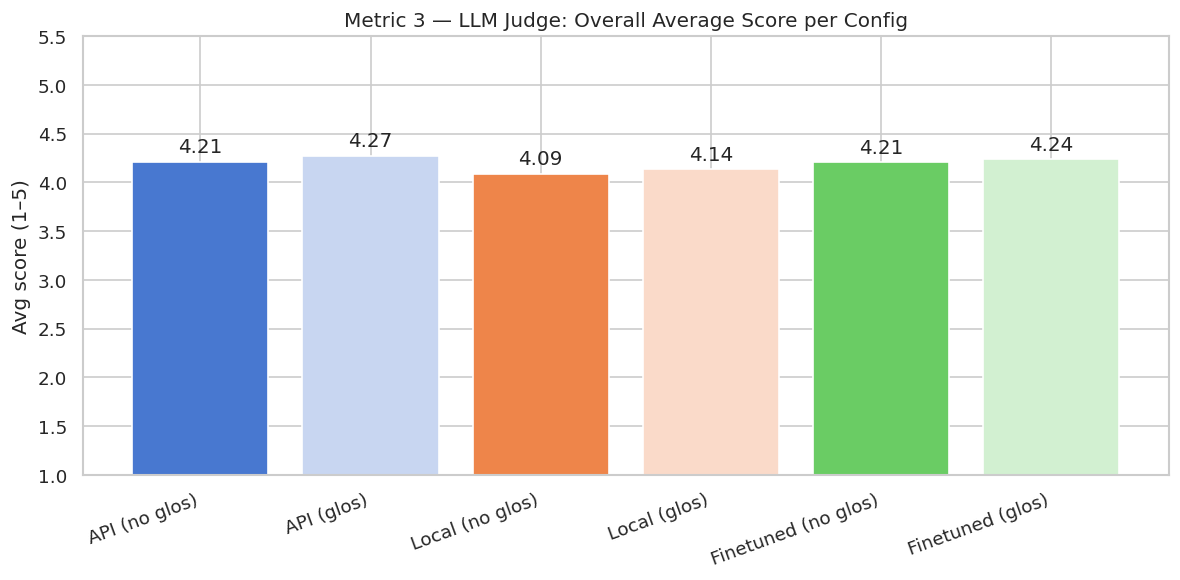

In [29]:
# --- Overall avg score per config (problem + solution combined) ---
overall = df.groupby('config')['overall'].mean().reindex(CONFIGS)

base_colors = sns.color_palette('muted', len(CONFIGS) // 2)
def lighten(color, factor=0.7):
    r, g, b = color
    return (r + (1 - r) * factor, g + (1 - g) * factor, b + (1 - b) * factor)

bar_colors = []
for i, c in enumerate(CONFIGS):
    base = base_colors[i // 2]
    bar_colors.append(lighten(base) if 'glos' in c and 'no_glos' not in c else base)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([LABELS[c] for c in CONFIGS], overall.values, color=bar_colors)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_ylim(1, 5.5)
ax.set_ylabel('Avg score (1–5)')
ax.set_title('Metric 3 — LLM Judge: Overall Average Score per Config')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

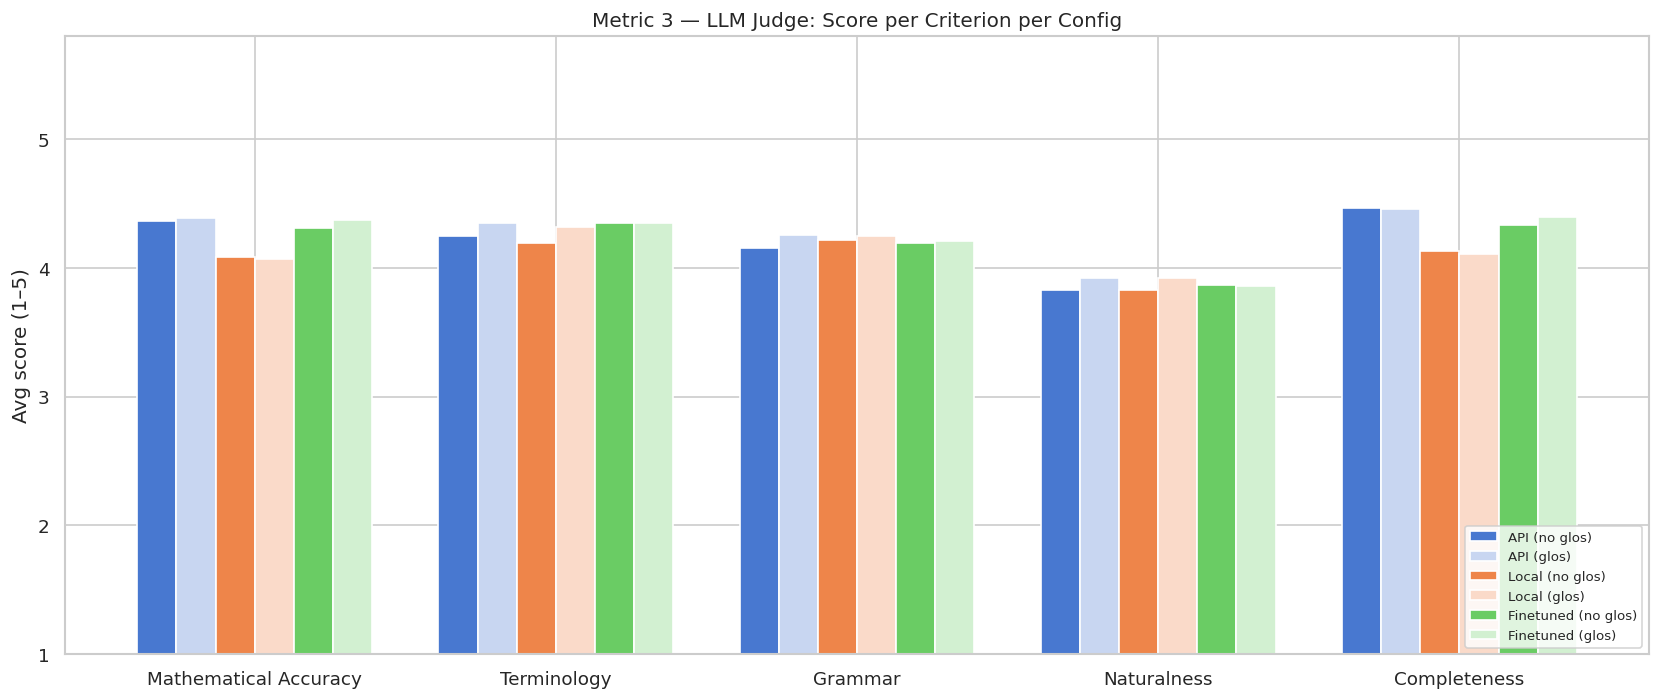

In [30]:
# --- Grouped bar: avg per criterion per config ---
crit_avgs = df.groupby('config')[CRITERIA].mean().reindex(CONFIGS)

base_colors = sns.color_palette('muted', len(CONFIGS) // 2)
def lighten(color, factor=0.7):
    r, g, b = color
    return (r + (1 - r) * factor, g + (1 - g) * factor, b + (1 - b) * factor)

colors = []
for i, c in enumerate(CONFIGS):
    base = base_colors[i // 2]
    colors.append(lighten(base) if 'glos' in c and 'no_glos' not in c else base)

x = np.arange(len(CRITERIA))
w = 0.13
fig, ax = plt.subplots(figsize=(14, 6))
for i, (ck, color) in enumerate(zip(CONFIGS, colors)):
    offset = (i - len(CONFIGS)/2 + 0.5) * w
    ax.bar(x + offset, crit_avgs.loc[ck], w, label=LABELS[ck], color=color)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ').title() for c in CRITERIA])
ax.set_ylim(1, 5.8)
ax.set_ylabel('Avg score (1–5)')
ax.set_title('Metric 3 — LLM Judge: Score per Criterion per Config')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

In [31]:
# # --- Radar chart: one polygon per config ---
# N = len(CRITERIA)
# angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
# angles += angles[:1]  # close polygon

# fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
# colors = sns.color_palette('muted', len(CONFIGS))
# for ck, color in zip(CONFIGS, colors):
#     vals = crit_avgs.loc[ck].tolist()
#     vals += vals[:1]
#     ax.plot(angles, vals, linewidth=1.5, label=LABELS[ck], color=color)
#     ax.fill(angles, vals, alpha=0.08, color=color)

# ax.set_xticks(angles[:-1])
# ax.set_xticklabels([c.replace('_', '\n').title() for c in CRITERIA], fontsize=9)
# ax.set_ylim(1, 5)
# ax.set_yticks([2, 3, 4, 5])
# ax.set_title('Metric 3 — LLM Judge: Radar Chart', pad=20)
# ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
# plt.tight_layout()
# plt.show()

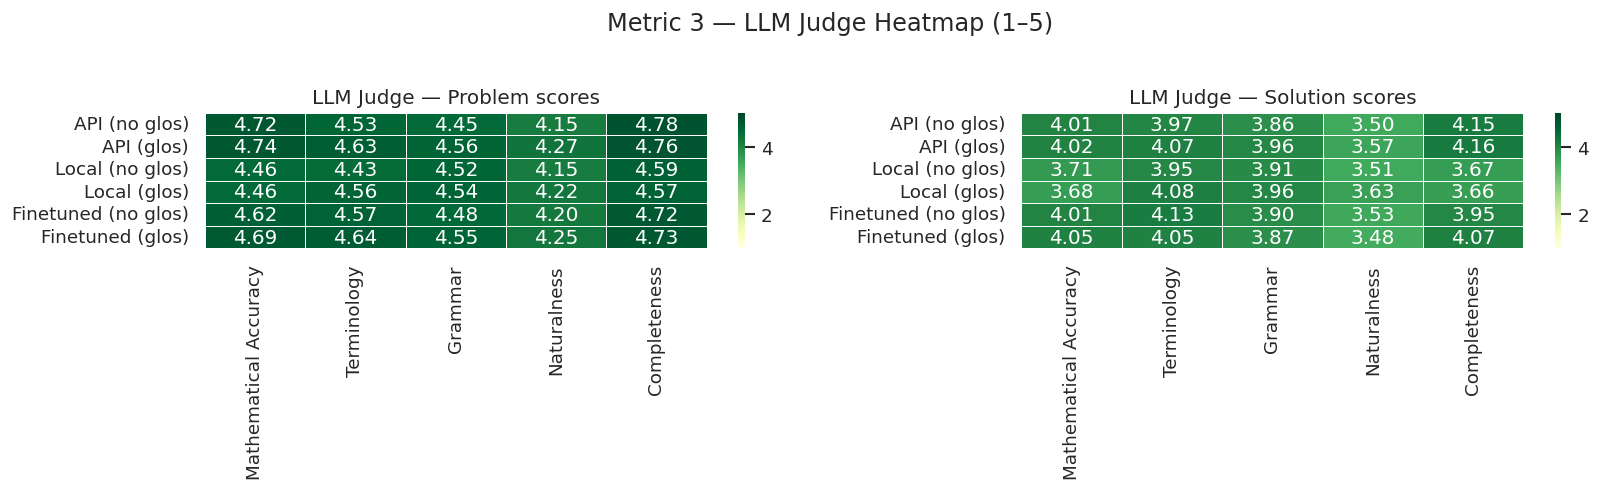

In [21]:
# --- Heatmap: config x criterion ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, part in zip(axes, ['problem', 'solution']):
    heat = df[df.part == part].groupby('config')[CRITERIA].mean().reindex(CONFIGS)
    heat.index = [LABELS[c] for c in CONFIGS]
    heat.columns = [c.replace('_', ' ').title() for c in CRITERIA]
    sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlGn', vmin=1, vmax=5,
                linewidths=0.5, ax=ax)
    ax.set_title(f'LLM Judge — {part.title()} scores')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.suptitle('Metric 3 — LLM Judge Heatmap (1–5)', y=1.02)
plt.tight_layout()
plt.show()

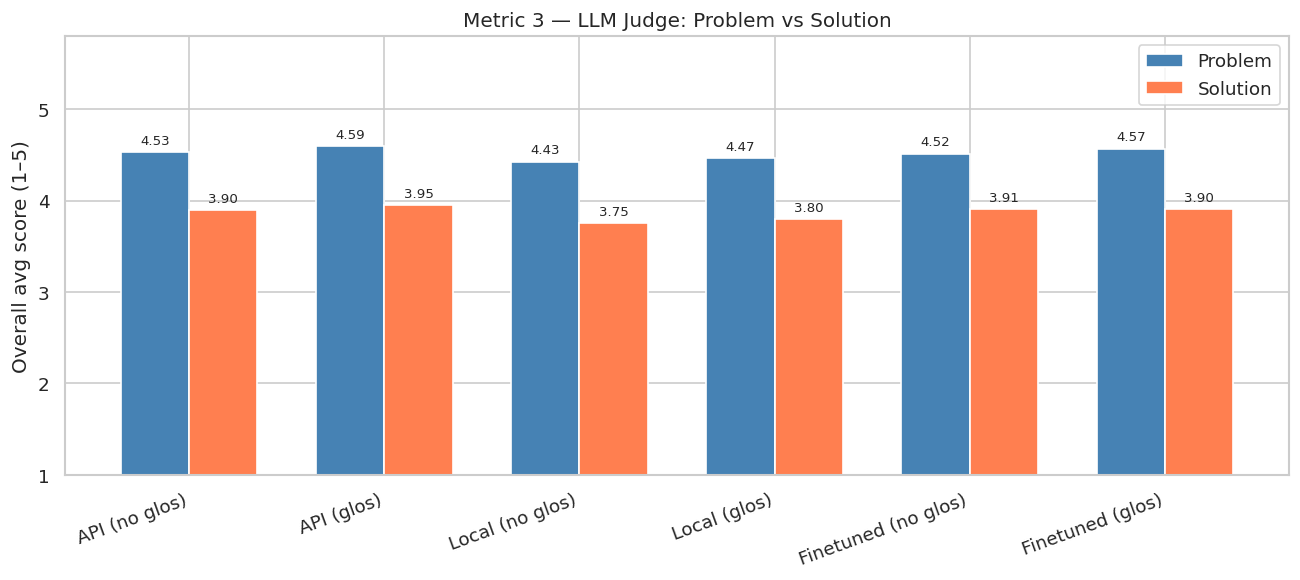

In [22]:
# --- Problem vs solution: overall avg per config ---
pv = df[df.part == 'problem'].groupby('config')['overall'].mean().reindex(CONFIGS)
sv = df[df.part == 'solution'].groupby('config')['overall'].mean().reindex(CONFIGS)

x = np.arange(len(CONFIGS))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, pv, w, label='Problem',  color='steelblue')
b2 = ax.bar(x + w/2, sv, w, label='Solution', color='coral')
ax.bar_label(b1, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.2f', padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([LABELS[c] for c in CONFIGS], rotation=20, ha='right')
ax.set_ylim(1, 5.8)
ax.set_ylabel('Overall avg score (1–5)')
ax.set_title('Metric 3 — LLM Judge: Problem vs Solution')
ax.legend()
plt.tight_layout()
plt.show()

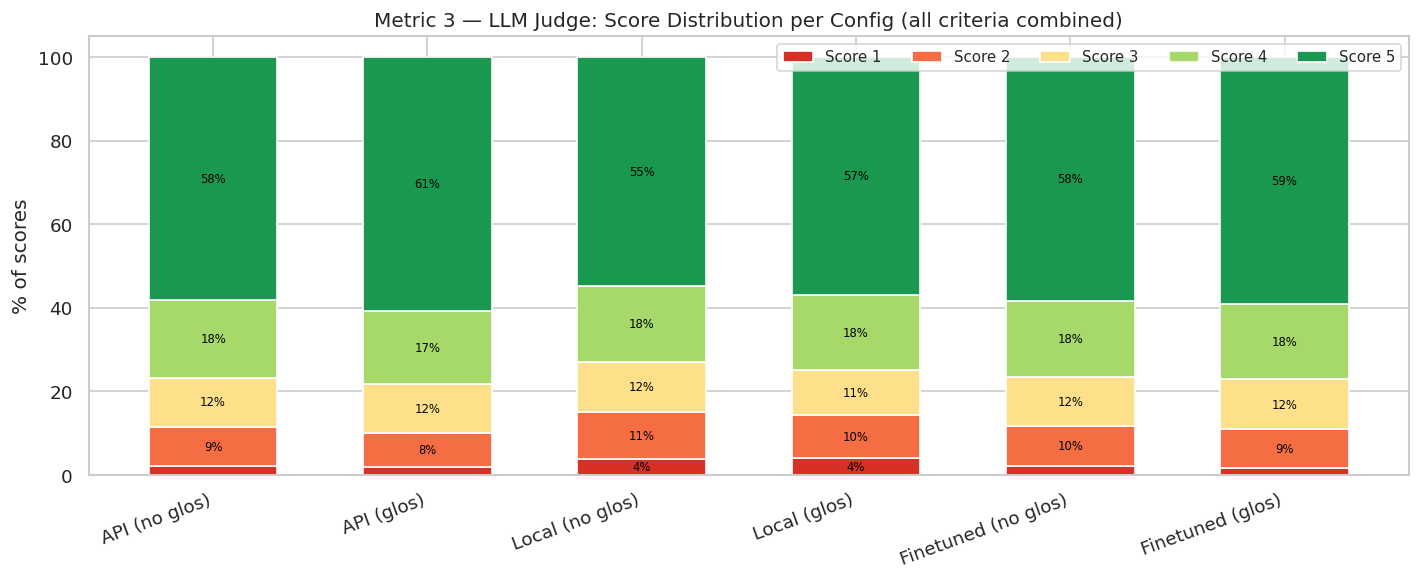

In [23]:
# --- Score distribution: stacked % bar showing how often each score (1-5) appears per config ---
score_vals = [1, 2, 3, 4, 5]
score_colors = ['#d73027', '#f46d43', '#fee08b', '#a6d96a', '#1a9850']

# melt all criteria into one column so we count across criteria + examples + parts
melted = df.melt(id_vars=['config'], value_vars=CRITERIA, value_name='score').dropna()
counts = melted.groupby(['config', 'score']).size().unstack(fill_value=0).reindex(CONFIGS)
pct = counts.div(counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(CONFIGS))
x = np.arange(len(CONFIGS))
for sv, color in zip(score_vals, score_colors):
    vals = pct[sv].values if sv in pct.columns else np.zeros(len(CONFIGS))
    bars = ax.bar(x, vals, bottom=bottom, color=color, label=f'Score {sv}', width=0.6)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 3:
            ax.text(xi, b + v / 2, f'{v:.0f}%', ha='center', va='center', fontsize=7, color='black')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([LABELS[c] for c in CONFIGS], rotation=20, ha='right')
ax.set_ylabel('% of scores')
ax.set_ylim(0, 105)
ax.set_title('Metric 3 — LLM Judge: Score Distribution per Config (all criteria combined)')
ax.legend(loc='upper right', fontsize=9, ncol=5)
plt.tight_layout()
plt.show()

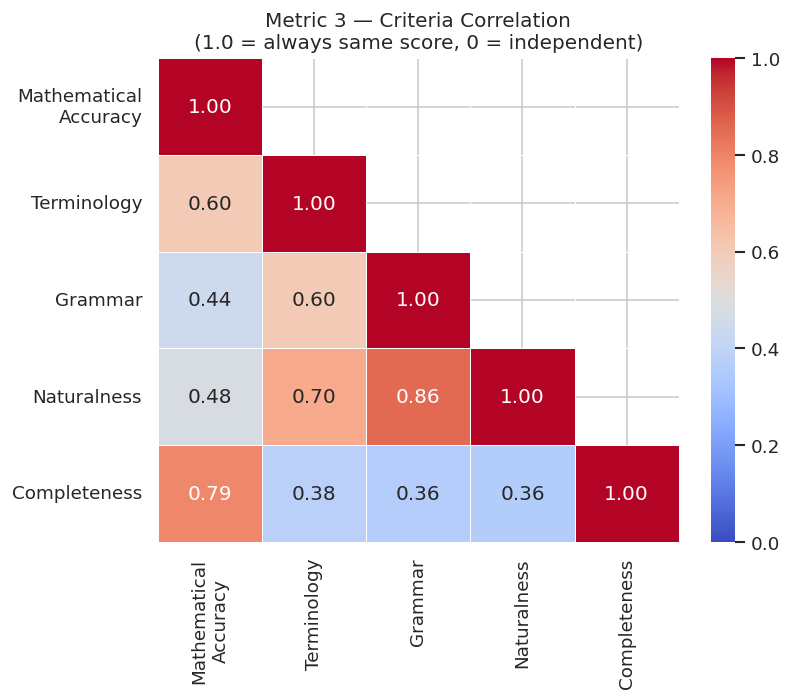

Criteria pairs with correlation > 0.85 (judge may not be distinguishing these):
  grammar  ↔  naturalness:  r=0.86


In [ ]:
# --- Criteria correlation: are the 5 judge criteria measuring independent things? ---
# High correlation (>0.8) between two criteria = judge is not really distinguishing them
corr = df[CRITERIA].corr()
labels = [c.replace('_', '\n').title() for c in CRITERIA]

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # show lower triangle + diagonal
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1,
    linewidths=0.5, ax=ax, mask=mask,
    xticklabels=labels, yticklabels=labels,
)
ax.set_title('Metric 3 — Criteria Correlation\n(1.0 = always same score, 0 = independent)')
plt.tight_layout()
plt.show()

print("Criteria pairs with correlation > 0.85 (judge may not be distinguishing these):")
for i, c1 in enumerate(CRITERIA):
    for j, c2 in enumerate(CRITERIA):
        if j <= i:
            continue
        v = corr.loc[c1, c2]
        if v > 0.85:
            print(f"  {c1}  ↔  {c2}:  r={v:.2f}")

####################################
# With dedications to Yulka
####################################

/tmp/ipykernel_776714/3287213767.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Glossary', y='Difference', ax=ax,
/tmp/ipykernel_776714/3287213767.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=data, x='Glossary', y='Difference', ax=ax,
/tmp/ipykernel_776714/3287213767.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Glossary', y='Difference', ax=ax,
/tmp/ipykernel_776714/3287213767.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

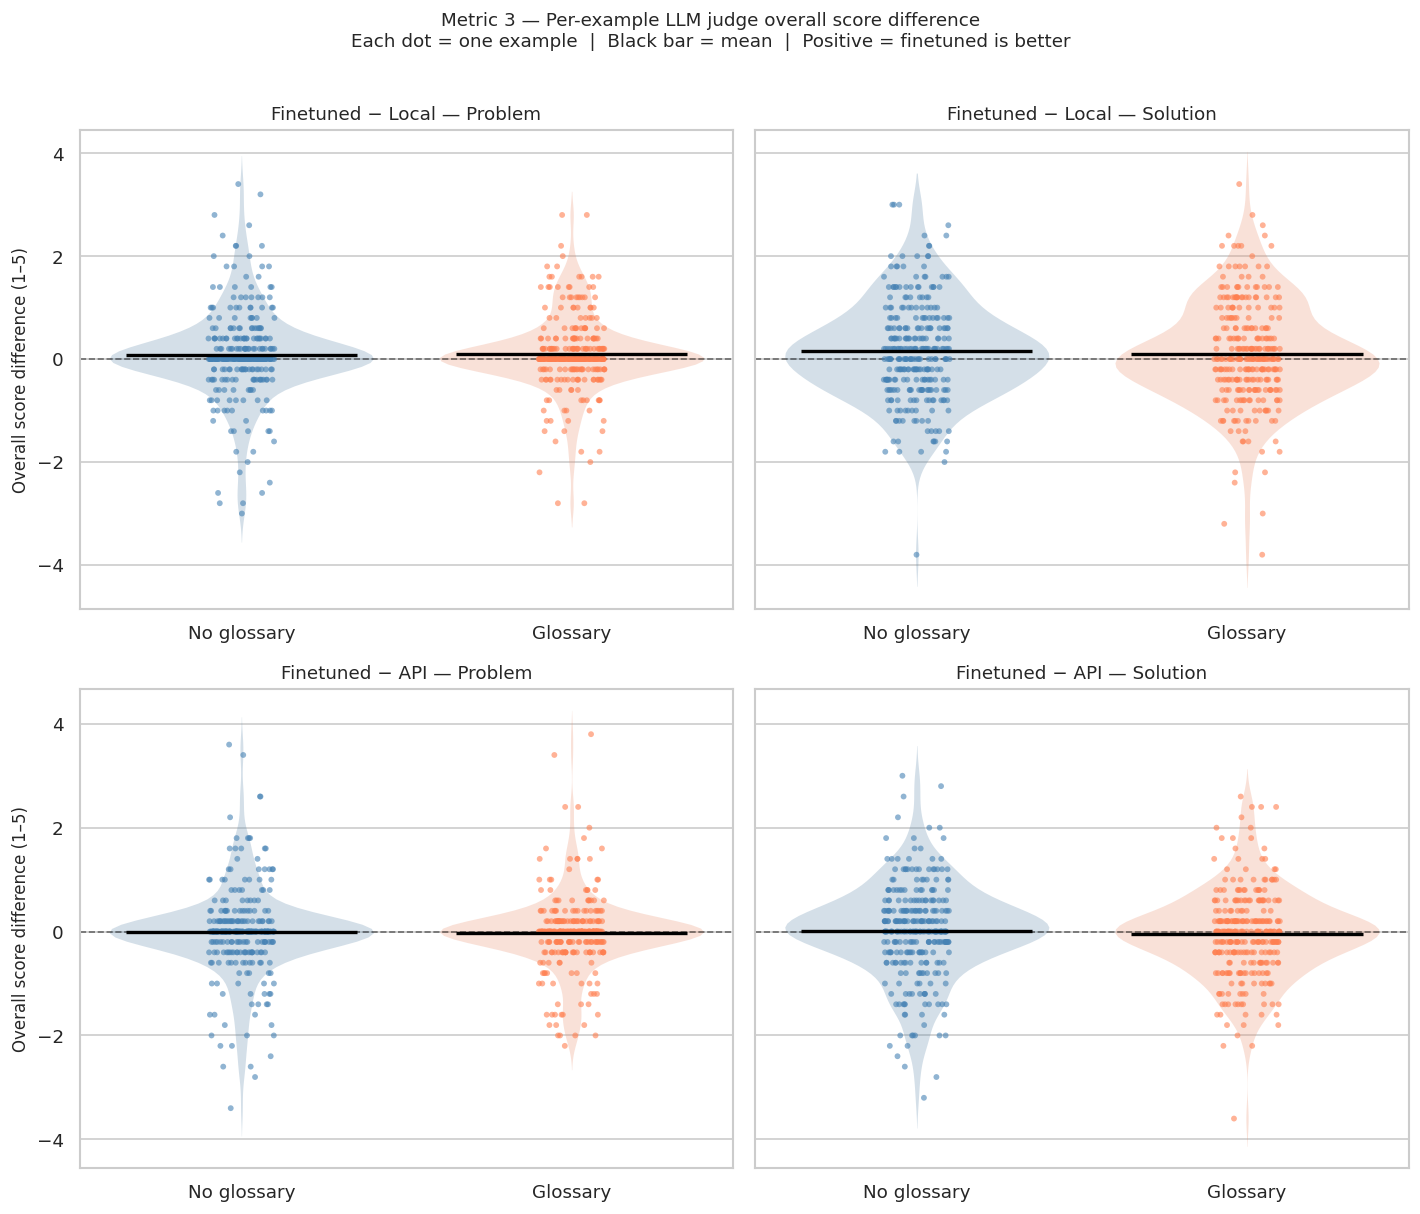

In [25]:
# --- Sina plot: per-example difference finetuned vs local and finetuned vs api (overall judge score) ---
df_prob3 = df[df.part == 'problem'].pivot(index='idx', columns='config', values='overall')
df_sol3  = df[df.part == 'solution'].pivot(index='idx', columns='config', values='overall')

comparisons = [
    ('finetuned', 'local', 'Finetuned − Local'),
    ('finetuned', 'api',   'Finetuned − API'),
]

records = []
for model_a, model_b, cmp_label in comparisons:
    for part, df_part in [('Problem', df_prob3), ('Solution', df_sol3)]:
        for suffix, glos_label in [('no_glos', 'No glossary'), ('glos', 'Glossary')]:
            col_a, col_b = f'{model_a}_{suffix}', f'{model_b}_{suffix}'
            if col_a not in df_part.columns or col_b not in df_part.columns:
                continue
            diff = (df_part[[col_a, col_b]].dropna()
                    .assign(diff=lambda d: d[col_a] - d[col_b])['diff'])
            for val in diff:
                records.append({'Comparison': cmp_label, 'Part': part,
                                 'Glossary': glos_label, 'Difference': val})

df_diff3 = pd.DataFrame(records)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey='row')

palette = {'No glossary': 'steelblue', 'Glossary': 'coral'}

for row_idx, cmp_label in enumerate(['Finetuned − Local', 'Finetuned − API']):
    for col_idx, part in enumerate(['Problem', 'Solution']):
        ax = axes[row_idx][col_idx]
        data = df_diff3[(df_diff3.Comparison == cmp_label) & (df_diff3.Part == part)]

        # violin for shape reference
        sns.violinplot(data=data, x='Glossary', y='Difference', ax=ax,
                       palette=palette, inner=None, alpha=0.25, linewidth=0)

        # individual dots
        sns.stripplot(data=data, x='Glossary', y='Difference', ax=ax,
                      palette=palette, size=3.5, alpha=0.6, jitter=True)

        # mean line per group
        for i, glos_label in enumerate(['No glossary', 'Glossary']):
            mean = data[data.Glossary == glos_label]['Difference'].mean()
            ax.hlines(mean, i - 0.35, i + 0.35, colors='black', linewidth=2, zorder=5)

        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_title(f'{cmp_label} — {part}', fontsize=11)
        ax.set_xlabel('')
        if col_idx == 0:
            ax.set_ylabel('Overall score difference (1–5)', fontsize=10)
        else:
            ax.set_ylabel('')

plt.suptitle(
    'Metric 3 — Per-example LLM judge overall score difference\n'
    'Each dot = one example  |  Black bar = mean  |  Positive = finetuned is better',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

In [26]:
# --- Load English source and Polish translations for example display ---
EVAL_SET_PATH3 = Path('../../eval_results/eval_set.jsonl')
TRANS_DIR3 = Path('../../eval_results/translations')

source3 = {}
if EVAL_SET_PATH3.exists():
    with open(EVAL_SET_PATH3) as f:
        for line in f:
            rec = json.loads(line)
            source3[rec['idx']] = rec

def _load_trans3(config_key):
    p = TRANS_DIR3 / f'{config_key}.jsonl'
    d = {}
    if p.exists():
        with open(p) as f:
            for line in f:
                rec = json.loads(line)
                d[rec['idx']] = rec
    return d

trans3 = {ck: _load_trans3(ck) for ck in CONFIGS}

def _trunc3(text, n=300):
    return (text[:n] + '…') if len(text) > n else text

# --- Top 2: finetuning improved most over local model (no glossary, avg overall across problem+solution) ---
ft_avg  = df[df.config == 'finetuned_no_glos'].groupby('idx')['overall'].mean()
loc_avg = df[df.config == 'local_no_glos'].groupby('idx')['overall'].mean()
improvement_ft3 = (ft_avg - loc_avg).dropna().sort_values(ascending=False)

print("══ Top 2 examples where finetuning improved most over local model (no glossary) ══\n")
for idx in improvement_ft3.head(2).index:
    src   = source3.get(idx, {})
    t_loc = trans3['local_no_glos'].get(idx, {})
    t_ft  = trans3['finetuned_no_glos'].get(idx, {})
    sc_loc = loc_avg.get(idx, float('nan'))
    sc_ft  = ft_avg.get(idx, float('nan'))
    print(f"idx={idx}   avg overall: local={sc_loc:.2f} → finetuned={sc_ft:.2f}  (Δ={sc_ft-sc_loc:+.2f})")
    print(f"\n  [EN problem]\n  {_trunc3(src.get('problem', ''))}")
    print(f"\n  [Local     ] score={sc_loc:.2f}\n  {_trunc3(t_loc.get('problem_pl', ''))}")
    print(f"\n  [Finetuned ] score={sc_ft:.2f}\n  {_trunc3(t_ft.get('problem_pl', ''))}")
    print("\n" + "─"*90 + "\n")

══ Top 2 examples where finetuning improved most over local model (no glossary) ══

idx=1495   avg overall: local=2.60 → finetuned=4.80  (Δ=+2.20)

  [EN problem]
  IV OM - III - Task 6

What algebraic relationship holds between $ \alpha $, $ \beta $, and $ \gamma $ when the equality is satisfied










翻译完成，但根据您的要求，最后一行似乎是不完整的。如果您需要进一步的信息或有其他任务，请告诉我。

  [Local     ] score=2.60
  IV OM - III - Zadanie 6

Jaka zależność algebraiczna zachodzi między $\alpha$, $\beta$ i $\gamma$, gdy spełniony jest równy

  [Finetuned ] score=4.80
  IV OM - III - Zadanie 6

Jaki związek algebraiczny zachodzi pomiędzy $ \alpha $, $ \beta $, a $ \gamma $, gdy jest spełniona równość

──────────────────────────────────────────────────────────────────────────────────────────

idx=1370   avg overall: local=2.00 → finetuned=4.00  (Δ=+2.00)

  [EN problem]
  I OM - B - Task 8

Prove that the altitudes of an acute triangle are the angle bisectors of the triangle whose vertices are the feet of these altitudes.



In [27]:
# --- Top 2: glossary improved most (avg overall improvement across all 3 models) ---
delta_sum3, delta_cnt3 = {}, {}
for m in ['api', 'local', 'finetuned']:
    no_g_avg3 = df[df.config == f'{m}_no_glos'].groupby('idx')['overall'].mean()
    gl_avg3   = df[df.config == f'{m}_glos'].groupby('idx')['overall'].mean()
    delta3 = (gl_avg3 - no_g_avg3).dropna()
    for i, v in delta3.items():
        delta_sum3[i] = delta_sum3.get(i, 0.0) + v
        delta_cnt3[i] = delta_cnt3.get(i, 0) + 1
improvement_glos3 = pd.Series(
    {i: delta_sum3[i] / delta_cnt3[i] for i in delta_sum3}
).sort_values(ascending=False)

print("══ Top 2 examples where glossary improved most (avg overall across models) ══\n")
for idx in improvement_glos3.head(2).index:
    src = source3.get(idx, {})
    # show the model with the largest improvement for this example
    best_m3 = max(
        ['api', 'local', 'finetuned'],
        key=lambda m: (
            df[df.config == f'{m}_glos'].groupby('idx')['overall'].mean().get(idx, -np.inf) -
            df[df.config == f'{m}_no_glos'].groupby('idx')['overall'].mean().get(idx, -np.inf)
        )
    )
    t_no3 = trans3[f'{best_m3}_no_glos'].get(idx, {})
    t_gl3 = trans3[f'{best_m3}_glos'].get(idx, {})
    sc_no3 = df[df.config == f'{best_m3}_no_glos'].groupby('idx')['overall'].mean().get(idx, float('nan'))
    sc_gl3 = df[df.config == f'{best_m3}_glos'].groupby('idx')['overall'].mean().get(idx, float('nan'))
    print(f"idx={idx}   avg Δ={improvement_glos3[idx]:+.2f}   (shown: {best_m3},  Δ={sc_gl3-sc_no3:+.2f})")
    print(f"\n  [EN problem]\n  {_trunc3(src.get('problem', ''))}")
    print(f"\n  [No glossary  ] score={sc_no3:.2f}\n  {_trunc3(t_no3.get('problem_pl', ''))}")
    print(f"\n  [With glossary] score={sc_gl3:.2f}\n  {_trunc3(t_gl3.get('problem_pl', ''))}")
    print("\n" + "─"*90 + "\n")

══ Top 2 examples where glossary improved most (avg overall across models) ══

idx=1427   avg Δ=+1.37   (shown: local,  Δ=+1.60)

  [EN problem]
  XXXIX OM - III - Problem 6

Calculate the maximum volume of a tetrahedron contained within a hemisphere of radius 1.

  [No glossary  ] score=2.90
  XXXIX OM - III - Zadanie 6

Oblicz maksymalną objętość czterościennego bryły zawartej w półsferze o promieniu 1.

  [With glossary] score=4.50
  XXXIX OM - III - Zadanie 6

Oblicz maksimum objętości czworościanu zawartego w półsferze o promieniu 1.

──────────────────────────────────────────────────────────────────────────────────────────

idx=1504   avg Δ=+1.13   (shown: local,  Δ=+1.30)

  [EN problem]
  LVII OM - II - Problem 2

Given a triangle $ABC$ where $AC + BC = 3AB$. The incircle of triangle $ABC$ with center $I$ is tangent to sides $BC$ and $CA$ at points $D$ and $E$, respectively. Let $K$ and $L$ be the points symmetric to $D$ and $E$ with respect to point $I$. Prove that points $A, 

In [32]:
# --- Bottom 2: glossary decreased quality most (avg overall improvement across all 3 models) ---
delta_sum3, delta_cnt3 = {}, {}
for m in ['api', 'local', 'finetuned']:
    no_g_avg3 = df[df.config == f'{m}_no_glos'].groupby('idx')['overall'].mean()
    gl_avg3   = df[df.config == f'{m}_glos'].groupby('idx')['overall'].mean()
    delta3 = (gl_avg3 - no_g_avg3).dropna()
    for i, v in delta3.items():
        delta_sum3[i] = delta_sum3.get(i, 0.0) + v
        delta_cnt3[i] = delta_cnt3.get(i, 0) + 1
improvement_glos3 = pd.Series(
    {i: delta_sum3[i] / delta_cnt3[i] for i in delta_sum3}
).sort_values(ascending=False)

print("══ Bottom 2 examples where glossary decreased quality most (avg overall across models) ══\n")
for idx in improvement_glos3.tail(2).index:
    src = source3.get(idx, {})
    # show the model with the largest decrease for this example
    best_m3 = min(
        ['api', 'local', 'finetuned'],
        key=lambda m: (
            df[df.config == f'{m}_glos'].groupby('idx')['overall'].mean().get(idx, np.inf) -
            df[df.config == f'{m}_no_glos'].groupby('idx')['overall'].mean().get(idx, np.inf)
        )
    )
    t_no3 = trans3[f'{best_m3}_no_glos'].get(idx, {})
    t_gl3 = trans3[f'{best_m3}_glos'].get(idx, {})
    sc_no3 = df[df.config == f'{best_m3}_no_glos'].groupby('idx')['overall'].mean().get(idx, float('nan'))
    sc_gl3 = df[df.config == f'{best_m3}_glos'].groupby('idx')['overall'].mean().get(idx, float('nan'))
    print(f"idx={idx}   avg Δ={improvement_glos3[idx]:+.2f}   (shown: {best_m3},  Δ={sc_gl3-sc_no3:+.2f})")
    print(f"\n  [EN problem]\n  {_trunc3(src.get('problem', ''))}")
    print(f"\n  [No glossary  ] score={sc_no3:.2f}\n  {_trunc3(t_no3.get('problem_pl', ''))}")
    print(f"\n  [With glossary] score={sc_gl3:.2f}\n  {_trunc3(t_gl3.get('problem_pl', ''))}")
    print("\n" + "─"*90 + "\n")

══ Bottom 2 examples where glossary decreased quality most (avg overall across models) ══

idx=1260   avg Δ=-0.70   (shown: api,  Δ=-1.50)

  [EN problem]
  XLVIII OM - I - Problem 7

Calculate the upper limit of the volume of tetrahedra contained within a sphere of a given radius $ R $, one of whose edges is the diameter of the sphere.

  [No glossary  ] score=4.20
  XLVIII OM - I - Zadanie 7

Oblicz górny limit objętości tetraedrów zawartych wewnątrz sfery o danym promieniu $ R $, jeden z których krawędzi jest średnicą sfery.

  [With glossary] score=2.70
  XLVIII OM - I - Zadanie 7

Oblicz górny limit objętości tetraedrów zawartych w kulie o danym promieniu $ R $, einer z których krawędzi jest średnicą kuli.

──────────────────────────────────────────────────────────────────────────────────────────

idx=1470   avg Δ=-0.80   (shown: local,  Δ=-1.20)

  [EN problem]
  XVII OM - II - Problem 6

Prove that the sum of the squares of the orthogonal projections of the sides of a triangle o